In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
print("All libraries loaded!")

Mounted at /content/drive
All libraries loaded!


In [2]:
df = pd.read_csv('/content/drive/MyDrive/house-price-project/data/USA_Housing.csv')
print("Shape:", df.shape)
df.head()

Shape: (5000, 7)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
print("=== SUMMARY STATISTICS ===")
display(df.describe())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== SUMMARY STATISTICS ===


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06



=== DATA TYPES ===
Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                          object
dtype: object

=== MISSING VALUES ===
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


In [6]:
import os
os.makedirs('/content/drive/MyDrive/house-price-project/reports', exist_ok=True)
print("Reports folder ready!")

Reports folder ready!


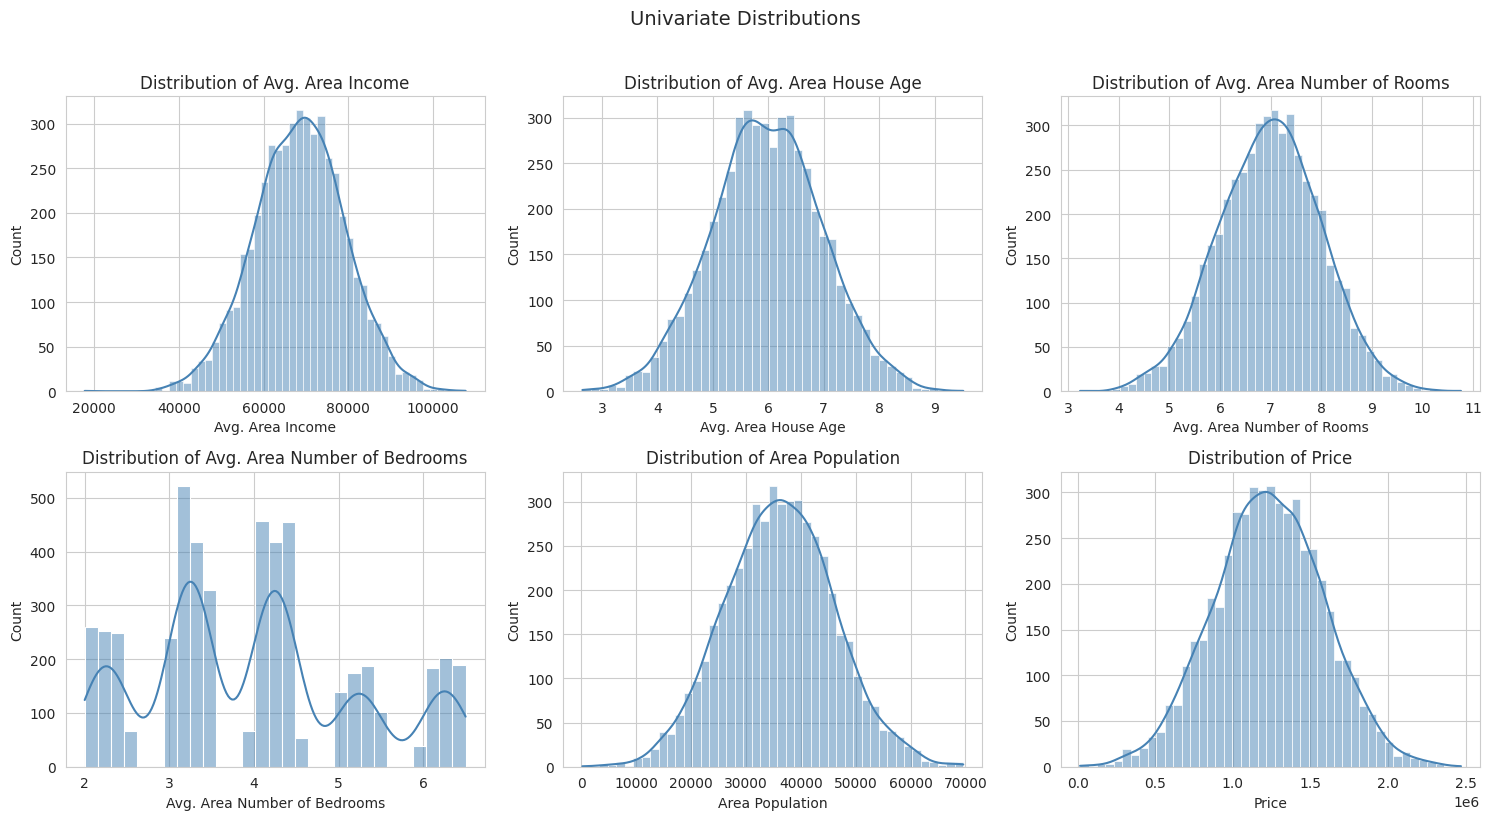

Saved!


In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.suptitle('Univariate Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week2_plot1_distributions.png', dpi=150)
plt.show()
print("Saved!")

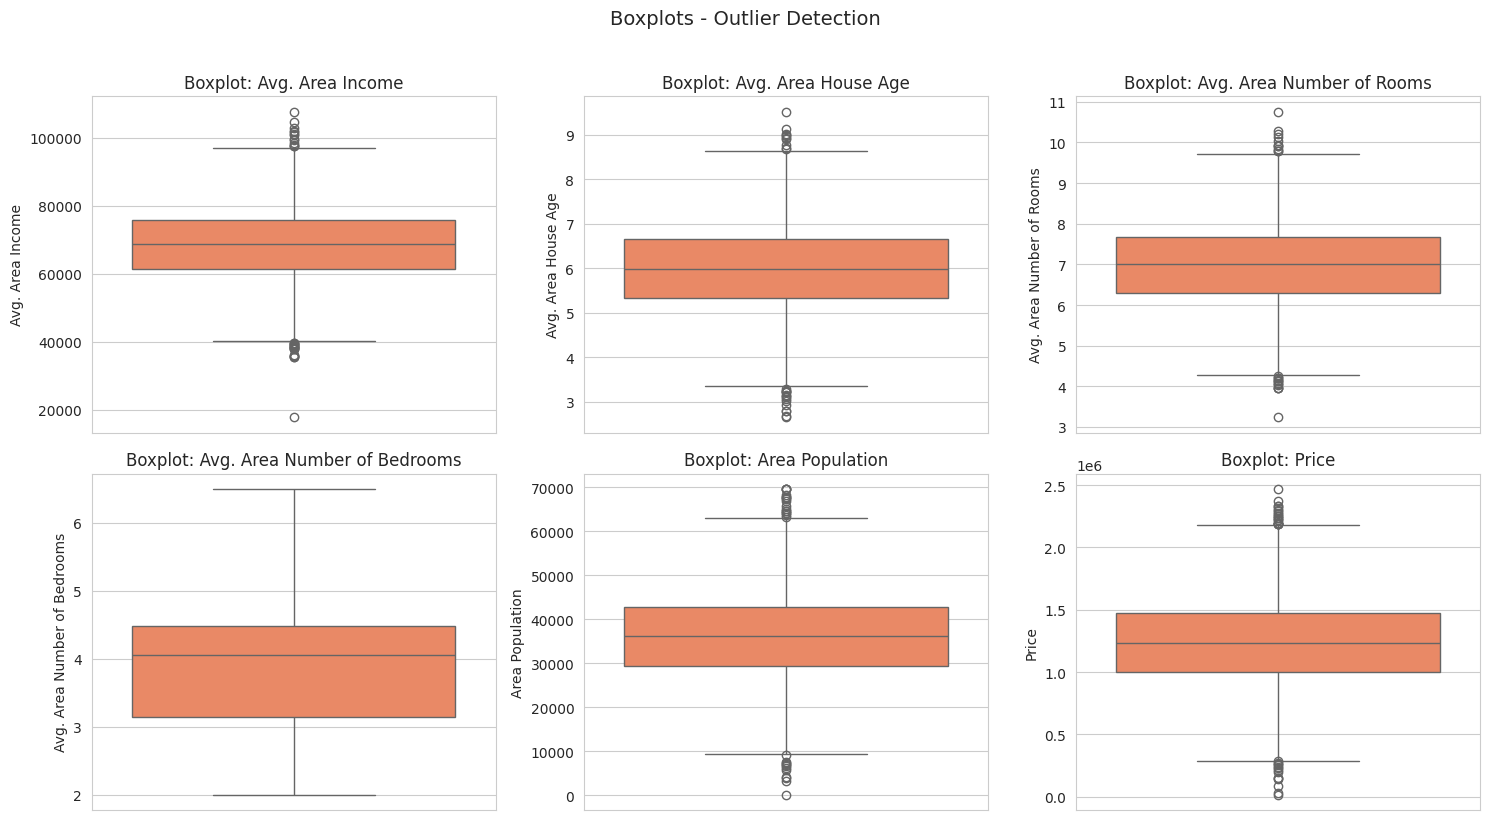

Saved!


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='coral')
    axes[i].set_title(f'Boxplot: {col}')

plt.suptitle('Boxplots - Outlier Detection', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week2_plot2_boxplots.png', dpi=150)
plt.show()
print("Saved!")

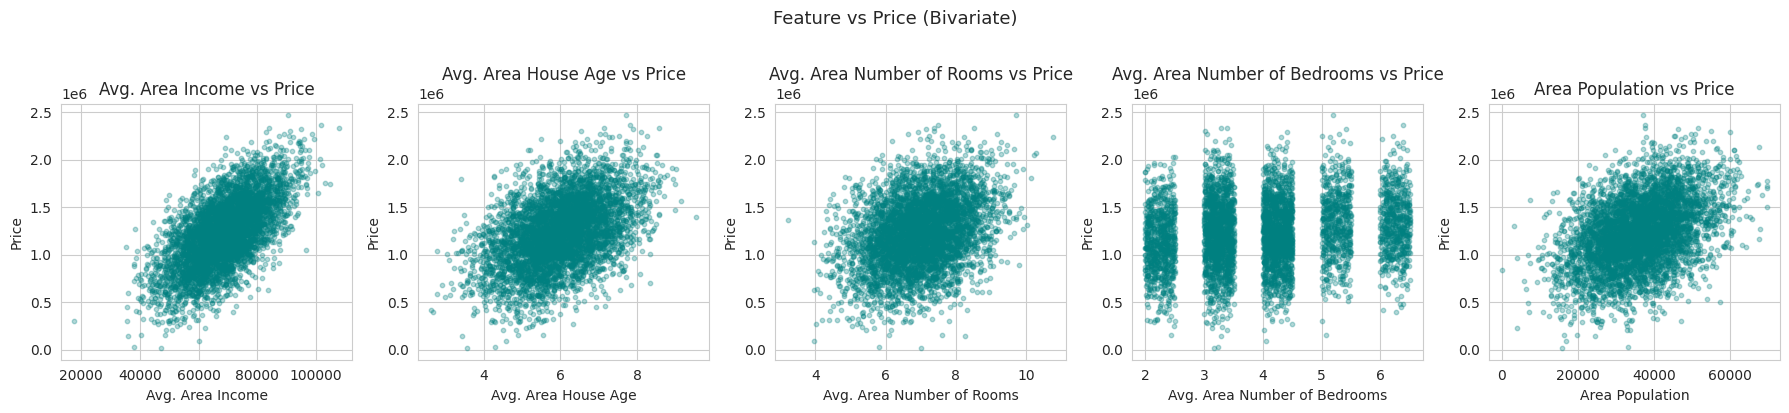

Saved!


In [9]:
feature_cols = [c for c in numeric_cols if c != 'Price']

fig, axes = plt.subplots(1, len(feature_cols), figsize=(18, 4))

for i, col in enumerate(feature_cols):
    axes[i].scatter(df[col], df['Price'], alpha=0.3, s=10, color='teal')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'{col} vs Price')

plt.suptitle('Feature vs Price (Bivariate)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week2_plot3_bivariate.png', dpi=150)
plt.show()
print("Saved!")

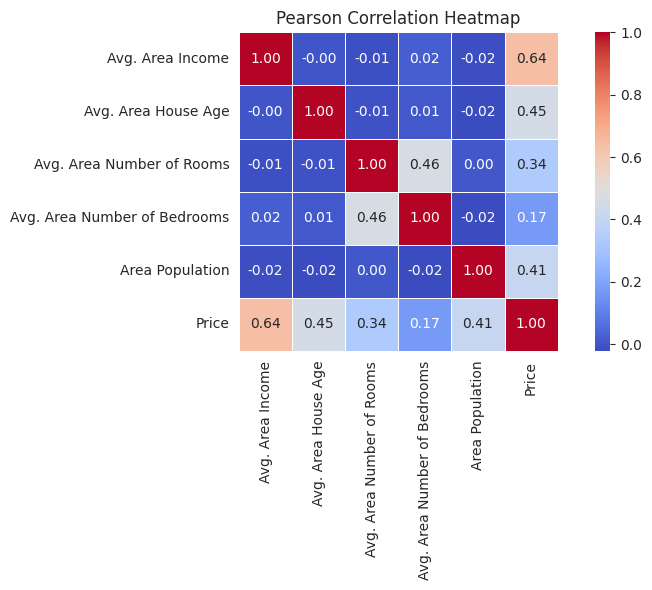


Top correlations with Price:
Price                           1.000000
Avg. Area Income                0.639734
Avg. Area House Age             0.452543
Area Population                 0.408556
Avg. Area Number of Rooms       0.335664
Avg. Area Number of Bedrooms    0.171071
Name: Price, dtype: float64


In [10]:
plt.figure(figsize=(9, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week2_plot4_heatmap.png', dpi=150)
plt.show()

# Print top correlations with Price
print("\nTop correlations with Price:")
print(corr['Price'].sort_values(ascending=False))

Generating pairplot... takes ~60 seconds


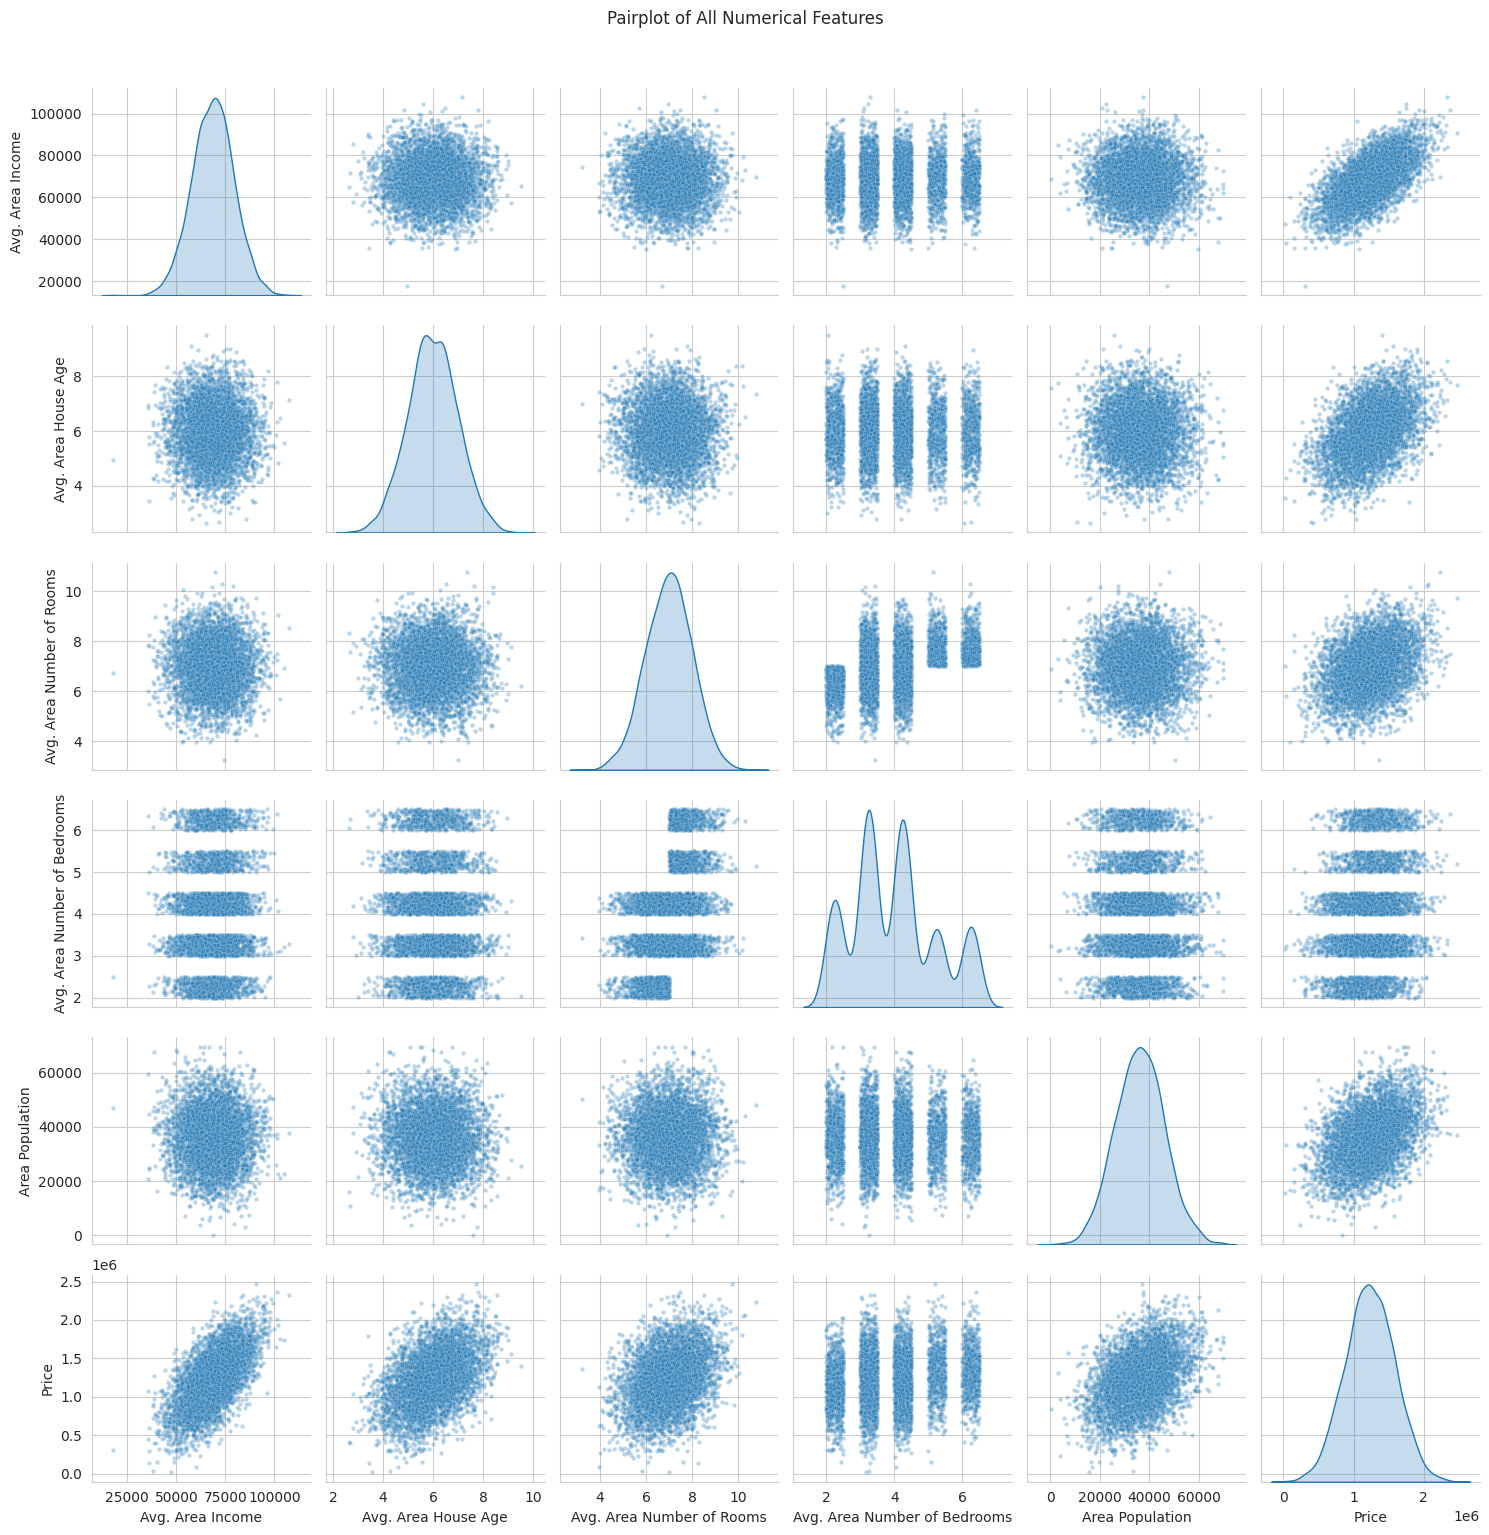

Saved!


In [11]:
print("Generating pairplot... takes ~60 seconds")
pp = sns.pairplot(df[numeric_cols], diag_kind='kde',
                  plot_kws={'alpha': 0.3, 's': 10})
pp.fig.suptitle('Pairplot of All Numerical Features', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week2_plot5_pairplot.png',
            dpi=100, bbox_inches='tight')
plt.show()
print("Saved!")

In [12]:
print("Missing values before cleaning:")
print(df.isnull().sum())

# USA Housing has no nulls but write this code for good practice
# For numerical: fill with median
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Filled {col} with median")

# For categorical: fill with mode
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"Filled {col} with mode")

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Missing values after cleaning:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


In [13]:
df_clean = df.copy()

print("Shape before outlier removal:", df_clean.shape)

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    removed = before - len(df_clean)
    print(f"{col}: removed {removed} outliers")

print("\nShape after outlier removal:", df_clean.shape)

Shape before outlier removal: (5000, 7)
Avg. Area Income: removed 32 outliers
Avg. Area House Age: removed 25 outliers
Avg. Area Number of Rooms: removed 25 outliers
Avg. Area Number of Bedrooms: removed 0 outliers
Area Population: removed 29 outliers
Price: removed 33 outliers

Shape after outlier removal: (4856, 7)


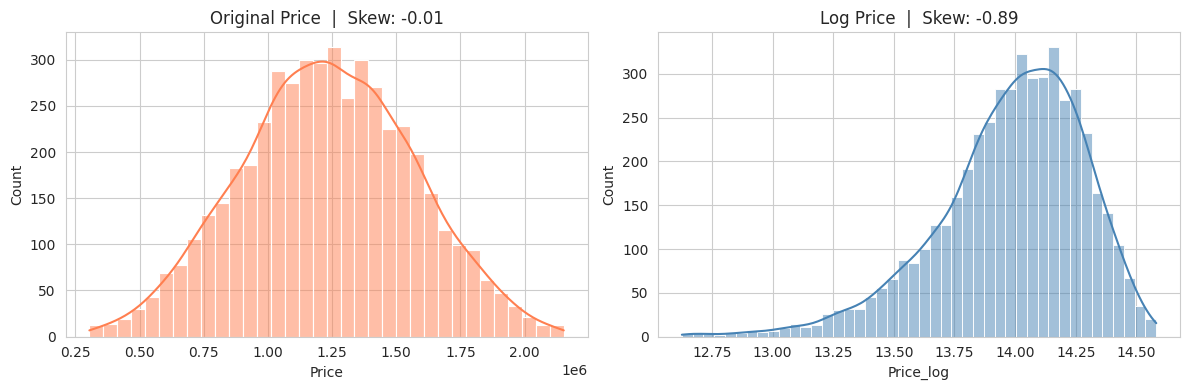

Saved!


In [14]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original
sns.histplot(df_clean['Price'], kde=True, ax=axes[0], color='coral')
axes[0].set_title(f'Original Price  |  Skew: {df_clean["Price"].skew():.2f}')

# Log transformed
df_clean['Price_log'] = np.log1p(df_clean['Price'])
sns.histplot(df_clean['Price_log'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title(f'Log Price  |  Skew: {df_clean["Price_log"].skew():.2f}')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week2_plot6_log_transform.png', dpi=150)
plt.show()
print("Saved!")

In [15]:
print("Columns before:", df_clean.columns.tolist())

# Drop Address (text, not useful for regression)
df_clean.drop(columns=['Address'], inplace=True)

print("Columns after:", df_clean.columns.tolist())
print("Shape:", df_clean.shape)

Columns before: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address', 'Price_log']
Columns after: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Price_log']
Shape: (4856, 7)


In [16]:
import os
os.makedirs('/content/drive/MyDrive/house-price-project/data/processed', exist_ok=True)

df_clean.to_csv('/content/drive/MyDrive/house-price-project/data/processed/cleaned_housing.csv', index=False)
print("✅ Cleaned dataset saved!")
print("Final shape:", df_clean.shape)
print("Columns:", df_clean.columns.tolist())

✅ Cleaned dataset saved!
Final shape: (4856, 7)
Columns: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Price_log']


## Week 2 Summary — EDA & Preprocessing

**Dataset:** USA Housing (5000 rows → cleaned)

**Univariate Findings:**
- Price is approximately normally distributed
- No missing values found in any column
- Some mild outliers detected in Price and Area Population

**Bivariate Findings:**
- Avg. Area Income has strongest correlation with Price (0.64)
- Avg. Area House Age has second highest (0.45)
- Number of Rooms and Bedrooms are correlated with each other (0.46)

**Preprocessing Done:**
- Missing values checked (none found)
- Outliers removed using IQR method
- Log transform applied to Price (reduces skewness)
- Address column dropped (irrelevant text)
- Cleaned dataset saved to data/processed/cleaned_housing.csv

**Next Step:** Week 3 — Feature Engineering